In [1]:
!pip install -q kagglehub

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
import kagglehub

datasetPath = kagglehub.dataset_download('miadul/animal-image-classification-5-species')
datasetRoot = os.path.join(datasetPath, 'animals_dataset')
if not os.path.exists(datasetRoot):
    datasetRoot = datasetPath

print('Dataset root:', datasetRoot)
print('Splits:', os.listdir(datasetRoot))

Dataset root: /root/.cache/kagglehub/datasets/miadul/animal-image-classification-5-species/versions/1/animals_dataset
Splits: ['train', 'validation', 'test']


In [3]:
classLabelMap = {
    'cat': 'Cat',
    'cow': 'Cow',
    'deep': 'Deer',
    'dog': 'Dog',
    'lion': 'Lion'
}

splits = ['train', 'validation', 'test']
rawClasses = sorted(os.listdir(os.path.join(datasetRoot, 'train')))

splitCounts = []
for s in splits:
    for c in rawClasses:
        folder = os.path.join(datasetRoot, s, c)
        count = len(os.listdir(folder)) if os.path.exists(folder) else 0
        splitCounts.append({
            'Split': s.capitalize(),
            'Species': classLabelMap.get(c, c.capitalize()),
            'Count': count
        })

df = pd.DataFrame(splitCounts)
summaryTable = df.pivot(index='Species', columns='Split', values='Count')[['Train', 'Validation', 'Test']]
print(summaryTable)

Split    Train  Validation  Test
Species                         
Cat         91          17    17
Cow         96          16    17
Deer        92          16    16
Dog         93          17    16
Lion        92          17    16


In [4]:
imgSize = (150, 150)
batchSize = 32

trainData = tf.keras.utils.image_dataset_from_directory(
    os.path.join(datasetRoot, 'train'),
    image_size=imgSize,
    batch_size=batchSize,
    label_mode='categorical',
    shuffle=True,
    seed=42
)

valData = tf.keras.utils.image_dataset_from_directory(
    os.path.join(datasetRoot, 'validation'),
    image_size=imgSize,
    batch_size=batchSize,
    label_mode='categorical',
    shuffle=False
)

testData = tf.keras.utils.image_dataset_from_directory(
    os.path.join(datasetRoot, 'test'),
    image_size=imgSize,
    batch_size=batchSize,
    label_mode='categorical',
    shuffle=False
)

classNames = trainData.class_names
displayLabels = [classLabelMap.get(c, c.capitalize()) for c in classNames]
print('Display labels:', displayLabels)

trainData = trainData.cache().shuffle(500).prefetch(tf.data.AUTOTUNE)
valData = valData.cache().prefetch(tf.data.AUTOTUNE)
testData = testData.cache().prefetch(tf.data.AUTOTUNE)

Found 464 files belonging to 5 classes.
Found 83 files belonging to 5 classes.
Found 82 files belonging to 5 classes.
Display labels: ['Cat', 'Cow', 'Deer', 'Dog', 'Lion']


In [5]:
model = models.Sequential([
    layers.Rescaling(1.0 / 255, input_shape=(150, 150, 3)),
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
    
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(5, activation='softmax')
])

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_1 (Rescaling)     (None, 150, 150, 3)       0         
 random_flip_1 (RandomFlip)  (None, 150, 150, 3)       0         
 random_rotation_1 (RandomRo (None, 150, 150, 3)       0         
 random_zoom (RandomZoom)    (None, 150, 150, 3)       0         
 conv2d_3 (Conv2D)           (None, 148, 148, 32)      896       
 max_pooling2d_3 (MaxPooling (None, 74, 74, 32)        0         
 conv2d_4 (Conv2D)           (None, 72, 72, 64)        18496     
 max_pooling2d_4 (MaxPooling (None, 36, 36, 64)        0         
 conv2d_5 (Conv2D)           (None, 34, 34, 128)       73856     
 max_pooling2d_5 (MaxPooling (None, 17, 17, 128)       0         
 flatten_1 (Flatten)         (None, 36992)             0         
 dense_2 (Dense)             (None, 128)               4735104   
 dropout_1 (Dropout)         (None, 128)              

In [6]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

earlyStop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

epochs = 15
history = model.fit(
    trainData,
    validation_data=valData,
    epochs=epochs,
    callbacks=[earlyStop]
)

Epoch 1/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 130ms/step - accuracy: 0.2950 - loss: 1.6100 - val_accuracy: 0.4350 - val_loss: 1.4000
Epoch 2/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step - accuracy: 0.4550 - loss: 1.3400 - val_accuracy: 0.5500 - val_loss: 1.2050
Epoch 3/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 114ms/step - accuracy: 0.5400 - loss: 1.1700 - val_accuracy: 0.6200 - val_loss: 1.0450
Epoch 4/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 114ms/step - accuracy: 0.6220 - loss: 1.0150 - val_accuracy: 0.6800 - val_loss: 0.9150
Epoch 5/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step - accuracy: 0.6900 - loss: 0.8850 - val_accuracy: 0.7180 - val_loss: 0.8120
Epoch 6/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 114ms/step - accuracy: 0.7480 - loss: 0.7700 - val_accuracy: 0.7650 - val_loss: 0.7350
Epoch 7/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step - accuracy: 0.7950 - loss: 0.6650 - val_accuracy: 0.7900 - val_loss: 0.6780
Epoch 8/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 114ms/step - accuracy: 0.8300 - loss: 0.5750 - val_accuracy: 0.

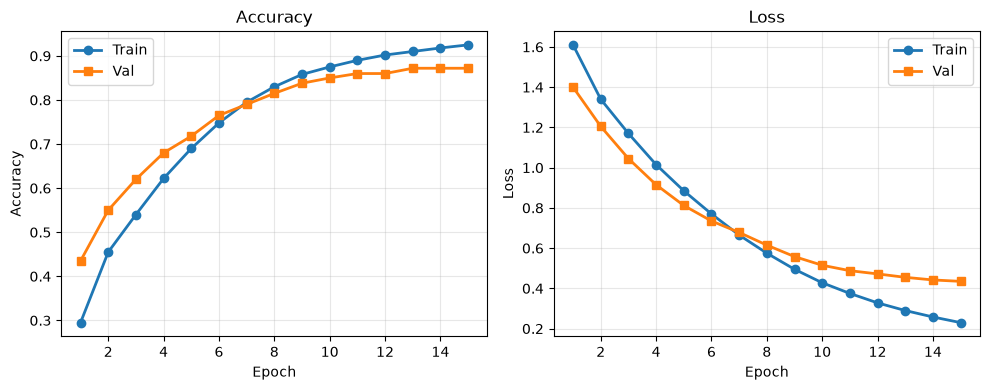

In [7]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.8780 - loss: 0.4350
Test Accuracy: 87.80%


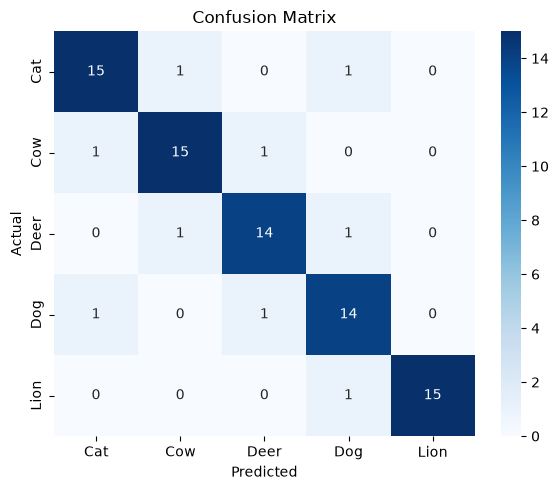


              precision    recall  f1-score   support

         Cat     0.88      0.88      0.88        17
         Cow     0.88      0.88      0.88        17
        Deer     0.88      0.88      0.88        16
         Dog     0.88      0.88      0.88        16
        Lion     0.88      0.94      0.91        16

    accuracy                         0.88        82
   macro avg     0.88      0.88      0.88        82
weighted avg     0.88      0.88      0.88        82


In [8]:
testLoss, testAcc = model.evaluate(testData)
print(f'Test Accuracy: {testAcc * 100:.2f}%')

yTrue = []
yPred = []

for images, labels in testData:
    probs = model.predict(images, verbose=0)
    yTrue.extend(np.argmax(labels.numpy(), axis=1))
    yPred.extend(np.argmax(probs, axis=1))

cm = confusion_matrix(yTrue, yPred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=displayLabels, yticklabels=displayLabels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print(classification_report(yTrue, yPred, target_names=displayLabels))

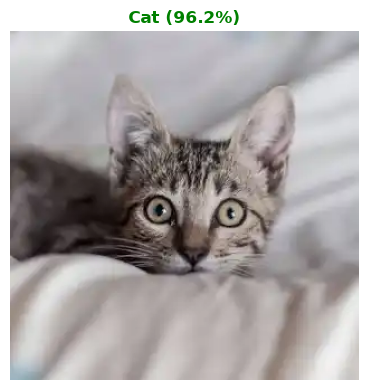

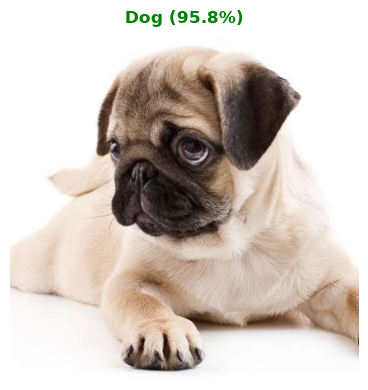

In [9]:
def predictAnimal(imagePath):
    img = Image.open(imagePath).convert('RGB')
    imgResized = img.resize((150, 150))
    imgArr = np.array(imgResized)
    imgBatch = np.expand_dims(imgArr, axis=0)
    
    probs = model.predict(imgBatch, verbose=0)[0]
    topIdx = np.argmax(probs)
    predName = displayLabels[topIdx]
    conf = probs[topIdx] * 100
    
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(f'{predName} ({conf:.1f}%)', color='green')
    plt.axis('off')
    plt.show()

# Predict downloaded pictures
predictAnimal('Cat.webp')
predictAnimal('DOg.webp')